In [5]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
    
import tensorflow as tf


/kaggle/input/imdb-dataset-sentiment-analysis-in-csv-format/Valid.csv
/kaggle/input/imdb-dataset-sentiment-analysis-in-csv-format/Train.csv
/kaggle/input/imdb-dataset-sentiment-analysis-in-csv-format/Test.csv


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import spacy
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

In [7]:
df=pd.read_csv('/kaggle/input/imdb-dataset-sentiment-analysis-in-csv-format/Test.csv')
df.head()

,text,label
0,I always wrote this series off as being a comp...,0
1,1st watched 12/7/2002 - 3 out of 10(Dir-Steve ...,0
2,This movie was so poorly written and directed ...,0
3,The most interesting thing about Miryang (Secr...,1
4,"when i first read about ""berlin am meer"" i did...",0


In [8]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [9]:
sentiment_count = Counter(df['label'])
print(sentiment_count)

Counter({1: 2505, 0: 2495})


# Data Exploration

## Sentiment distribution

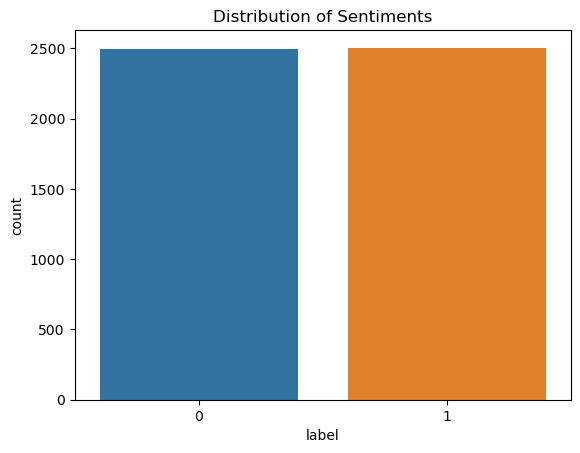

In [10]:
sns.countplot(x='label', data=df)
plt.title('Distribution of Sentiments')
plt.show()

The label has positive and negative sentiments equal in number therefore the dataframe is balanced.

## length of the text in my data

In [11]:
df['text_length'] = df['text'].apply(len)

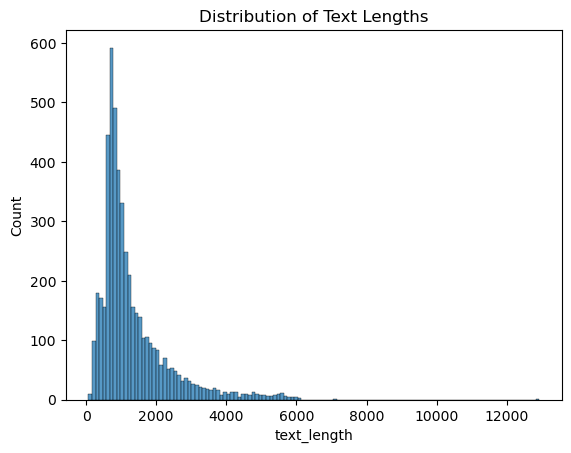

In [12]:
sns.histplot(x='text_length', data=df)
##plt.xlim(0, 2000)
plt.title('Distribution of Text Lengths')
plt.show()

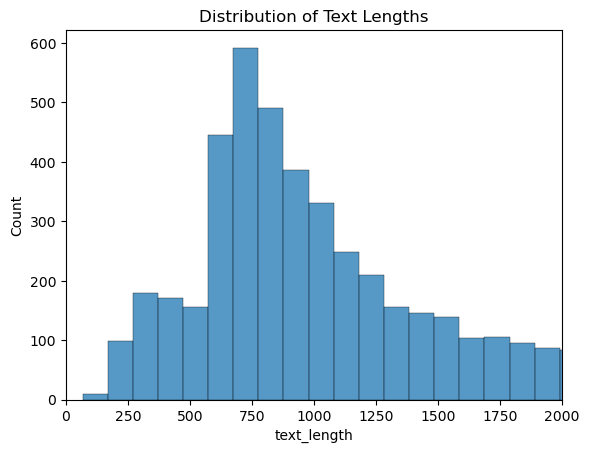

In [13]:
sns.histplot(x='text_length', data=df)
plt.xlim(0, 2000)
plt.title('Distribution of Text Lengths')
plt.show()

As we can see some reviews are over 6000 words long, for better results dropping of such massive reviews, and limiting the reviews to only be of maximum 1500 words in length

In [14]:
xmin = 0
xmax = 1500

# Boolean indexing to split the DataFrame
mask = (df['text'].apply(len) >= xmin) & (df['text'].apply(len) <= xmax)
df_range = df.loc[mask].copy() 

In [15]:
df_range['text_length'] = df_range['text'].apply(len)

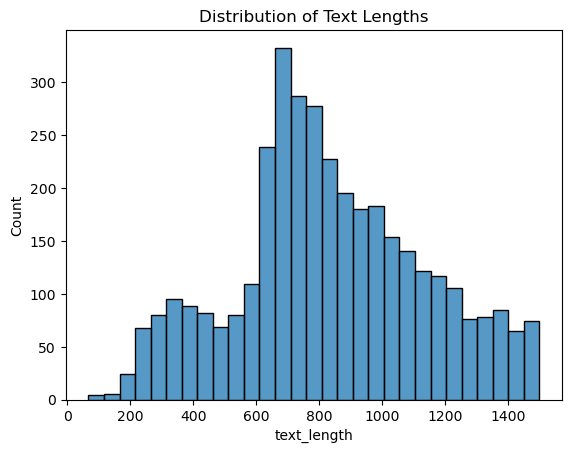

In [16]:
sns.histplot(x='text_length', data=df_range)
plt.title('Distribution of Text Lengths')
plt.show()

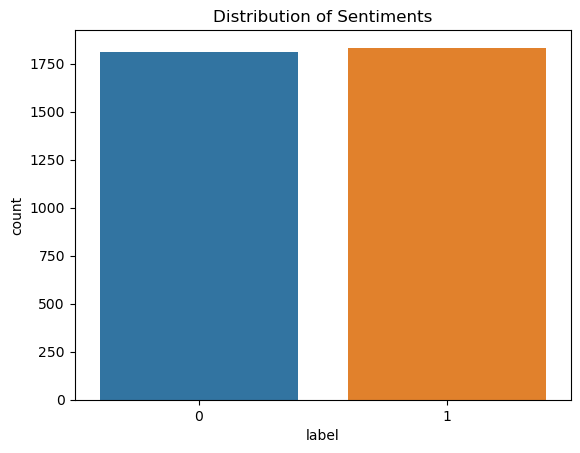

In [17]:
sns.countplot(x='label', data=df_range)
plt.title('Distribution of Sentiments')
plt.show()

   Dataframe is still balanced overall, now we can perform predictions!

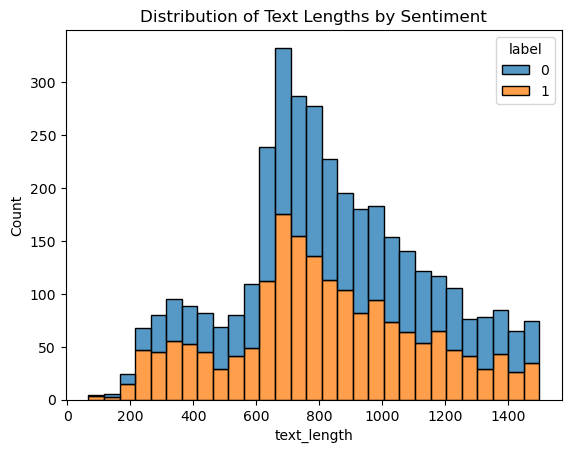

In [18]:
sns.histplot(x='text_length', data=df_range, hue='label', multiple='stack')
plt.title('Distribution of Text Lengths by Sentiment')
plt.show()

# Data preprocessing

In [19]:
df_range['text'] = df_range['text'].apply(lambda x: re.sub(r'\W', ' ', str(x))) # remove non-alphanumeric characters

In [20]:
df_range['text'] = df_range['text'].apply(lambda x: re.sub(r'\s+[a-zA-Z]\s+', ' ', x)) # remove single character words

In [21]:
df_range['text'] = df_range['text'].apply(lambda x: re.sub(r'\^[a-zA-Z]\s+', ' ', x)) # remove single characters at the beginning of text

In [22]:
df_range['text'] = df_range['text'].apply(lambda x: re.sub(r'\s+', ' ', x, flags=re.I)) # replace multiple spaces with single space

In [23]:
df_range['text'] = df_range['text'].apply(lambda x: x.lower()) # convert to lowercase

In [24]:
nlp = spacy.load('en_core_web_sm')
stopwords = nlp.Defaults.stop_words
df_range['text_processed'] = df_range['text'].apply(lambda x: ' '.join([token.text for token in nlp(x) if not token.is_stop and not token.is_punct]))

In [25]:
df_range.head()

,text,label,text_length,text_processed
1,1st watched 12 7 2002 3 out of 10 dir steve pu...,0,1070,1st watched 12 7 2002 3 10 dir steve purcell t...
2,this movie was so poorly written and directed ...,0,1402,movie poorly written directed fell asleep 30 m...
4,when first read about berlin am meer didn expe...,0,1013,read berlin meer didn expect thought right peo...
6,i saw screening of this movie last night had h...,0,1470,saw screening movie night high expectations go...
7,william hurt may not be an american matinee id...,1,955,william hurt american matinee idol anymore pre...


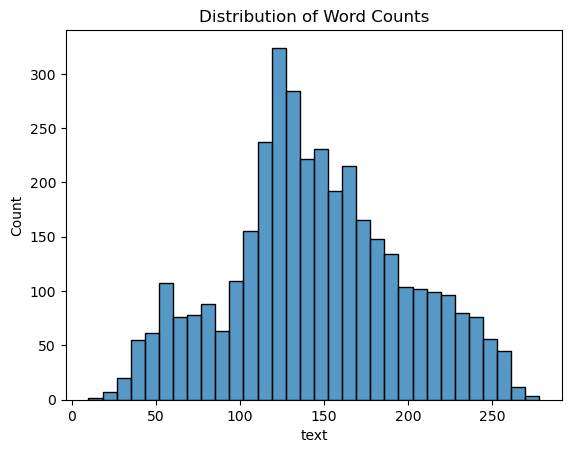

In [26]:
word_count = df_range['text'].apply(lambda x: len(x.split()))
sns.histplot(word_count)
plt.title('Distribution of Word Counts')
plt.show()

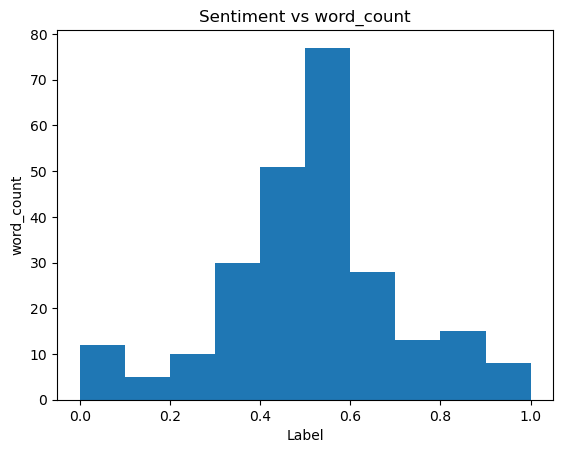

In [27]:
df_range['word_count'] = word_count
df_range.groupby('word_count')['label'].mean().plot.hist()
#plt.title('Sentiment Distribution by Word Count')
plt.ylabel('word_count')
#plt.xticks(rotation=90)
plt.xlabel('Label')
plt.title('Sentiment vs word_count')
plt.savefig('Sentiment vs word_count')
plt.show()
plt.show()

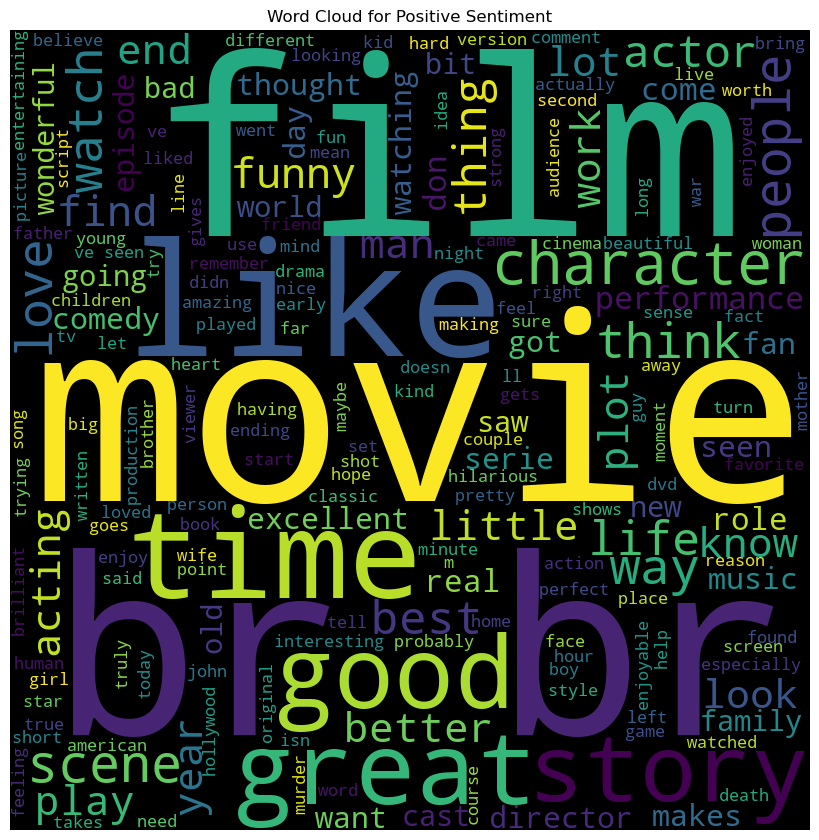

In [28]:
positive_texts = df_range[df_range['label'] == 1]['text_processed']
positive_wordcloud = WordCloud(width=800, height=800, background_color='black', stopwords=set()).generate(' '.join(positive_texts))
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(positive_wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Word Cloud for Positive Sentiment')
plt.show()

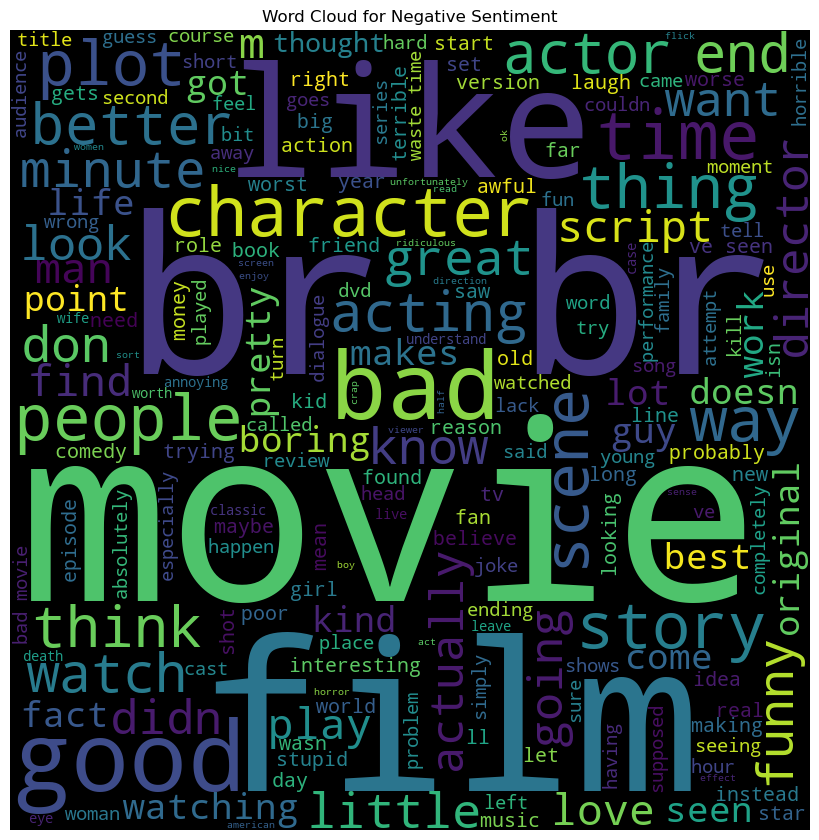

In [29]:
negative_texts = df_range[df_range['label'] == 0]['text_processed']
negative_wordcloud = WordCloud(width=800, height=800, background_color='black', stopwords=set()).generate(' '.join(negative_texts))
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(negative_wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Word Cloud for Negative Sentiment')
plt.show()

# Stemming

In [30]:
from nltk.corpus import stopwords

nltk.download('stopwords')
ps = PorterStemmer()
df_range['text'] = df_range['text'].apply(lambda x: ' '.join([ps.stem(word) for word in x.split() if word not in set(stopwords.words('english'))]))
df_range['text_processed'] = df_range['text_processed'].apply(lambda x: ' '.join([ps.stem(word) for word in x.split() if word not in set(stopwords.words('english'))]))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
#randomization
df_range = df_range.sample(frac=1).reset_index(drop=True)
df_range.head()

,text,label,text_length,text_processed,word_count
0,famili delight last blond bombshel purchas cop...,1,649,famili delight blond bombshel purchas copi hom...,121
1,think movi like would releas today take time p...,1,1194,think movi like releas today take time present...,212
2,1990 saw kathi ireland person unt denton film ...,0,1197,1990 saw kathi ireland person unt denton film ...,207
3,best movi ever made babett feast certainli amo...,1,732,best movi babett feast certainli love wonder e...,115
4,opinion good exampl movi could much better sho...,1,1181,opinion good exampl movi better short 10 year ...,205


# Vectorization

In [33]:
accuracy = {'TF-IDF': [],
            'BoW': []}

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [39]:
X = df_range['text']
y = df_range['label']


vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds.round())
accuracy['TF-IDF'].append(lr_acc)


lgr = LogisticRegression()
lgr.fit(X_train, y_train)
lgr_preds = lgr.predict(X_test)
lgr_acc = accuracy_score(y_test, lgr_preds)
accuracy['TF-IDF'].append(lgr_acc)


dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
accuracy['TF-IDF'].append(dt_acc)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
accuracy['TF-IDF'].append(rf_acc)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)
accuracy['TF-IDF'].append(knn_acc)


print(f"Linear Regression Accuracy: {lr_acc}")
print(f"Logistic Regression Accuracy: {lgr_acc}")
print(f"Decision Tree Accuracy: {dt_acc}")
print(f"Random Forest Accuracy: {rf_acc}")
print(f"KNN Accuracy: {knn_acc}")

Linear Regression Accuracy: 0.7767123287671233
Logistic Regression Accuracy: 0.8438356164383561
Decision Tree Accuracy: 0.6602739726027397
Random Forest Accuracy: 0.8082191780821918
KNN Accuracy: 0.5287671232876713


# Hyperparameter Tuning

In [37]:
import warnings
warnings.filterwarnings('ignore')

In [38]:
from sklearn.model_selection import GridSearchCV
train_size = int(len(df_range) * 0.8)
train_data = df_range[:train_size]
test_data = df_range[train_size:]
tfidf = TfidfVectorizer()
tfidf.fit(train_data['text'])
X_train = tfidf.transform(train_data['text'])
X_test = tfidf.transform(test_data['text'])

## 1. Logistic Regression

In [42]:

lr = LogisticRegression()
hyperparameters = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_search = GridSearchCV(lr, hyperparameters, cv=5)
grid_search.fit(X_train, train_data['label'])
best_params = grid_search.best_params_
lr = LogisticRegression(**best_params)
lr.fit(X_train, train_data['label'])

a = lr.score(X_test, test_data['label'])
print("Accuracy:", a)
accuracy['TF-IDF'].append(a)

Accuracy: 0.4945205479452055


## 2. Decision Tree

In [43]:
hyperparameters = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10, 15]
}
dt = DecisionTreeClassifier()
grid_search = GridSearchCV(dt, hyperparameters, cv=5)
grid_search.fit(X_train, train_data['label'])
best_params = grid_search.best_params_

dt = DecisionTreeClassifier(**best_params)
dt.fit(X_train, train_data['label'])
a = dt.score(X_test, test_data['label'])
print("Accuracy:", a)
accuracy['TF-IDF'].append(a)

Accuracy: 0.5082191780821917


# 3. Random Forest

In [44]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier()
grid_search = GridSearchCV(rf, param_grid, cv=5)
grid_search.fit(X_train, train_data['label'])

best_params = grid_search.best_params_
rf = RandomForestClassifier(**best_params)
rf.fit(X_train, train_data['label'])
a = rf.score(X_test, test_data['label'])
print("Accuracy:", a)
accuracy['TF-IDF'].append(a)

Accuracy: 0.5260273972602739


# 4. KNN 

In [41]:
hyperparameters = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, hyperparameters, cv=5)
grid_search.fit(X_train, train_data['label'])

best_params = grid_search.best_params_

knn = KNeighborsClassifier(**best_params)
knn.fit(X_train, train_data['label'])
a = knn.score(X_test, test_data['label'])
print("Accuracy:", a)
accuracy['TF-IDF'].append(a)

Accuracy: 0.5068493150684932


# Plots of Vectorization

In [45]:
del accuracy['TF-IDF'][9:]
accuracy['TF-IDF']

[0.7767123287671233,
 0.8438356164383561,
 0.6602739726027397,
 0.8082191780821918,
 0.5287671232876713,
 0.5068493150684932,
 0.4945205479452055,
 0.5082191780821917,
 0.5260273972602739]

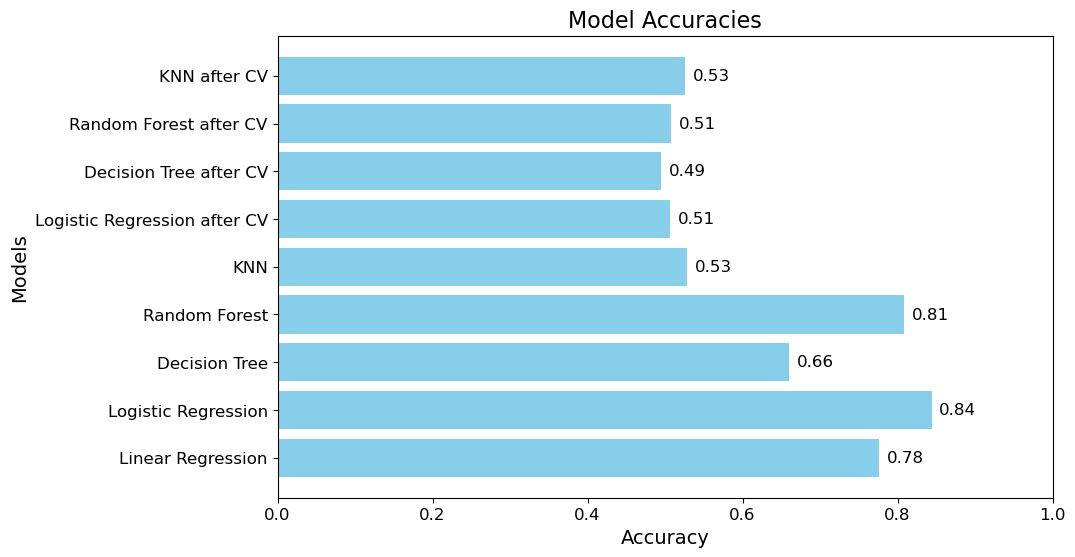

In [46]:
models = ['Linear Regression', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 
          'Logistic Regression after CV', 'Decision Tree after CV', 'Random Forest after CV', 'KNN after CV']
accuracies = accuracy['TF-IDF']
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(models, accuracies, color='skyblue')
ax.set_title('Model Accuracies', fontsize=16)
ax.set_xlabel('Accuracy', fontsize=14)
ax.set_ylabel('Models', fontsize=14)
ax.set_xlim(0, 1)
ax.tick_params(axis='both', labelsize=12)
for i, acc in enumerate(accuracies):
    ax.text(acc+0.01, i, f'{acc:.2f}', va='center', fontsize=12)

plt.show()

# Bag of Words:

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [47]:

X = df_range['text']
y = df_range['label']

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds.round())
accuracy['BoW'].append(lr_acc)

lgr = LogisticRegression()
lgr.fit(X_train, y_train)
lgr_preds = lgr.predict(X_test)
lgr_acc = accuracy_score(y_test, lgr_preds)
accuracy['BoW'].append(lgr_acc)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
accuracy['BoW'].append(dt_acc)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
accuracy['BoW'].append(rf_acc)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)
accuracy['BoW'].append(knn_acc)

print(f"Linear Regression Accuracy: {lr_acc}")
print(f"Logistic Regression Accuracy: {lgr_acc}")
print(f"Decision Tree Accuracy: {dt_acc}")
print(f"Random Forest Accuracy: {rf_acc}")
print(f"KNN Accuracy: {knn_acc}")


Linear Regression Accuracy: 0.7027397260273973
Logistic Regression Accuracy: 0.8356164383561644
Decision Tree Accuracy: 0.7465753424657534
Random Forest Accuracy: 0.810958904109589
KNN Accuracy: 0.589041095890411


# Hyperparameter tuning

In [41]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
X = df_range['text']
y = df_range['label']

# 1. Logistic regression

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
param_grid = {'C': [0.1, 1, 10, 100],
              'penalty': ['l1', 'l2']}

lr_gs = GridSearchCV(LogisticRegression(), param_grid, cv=5)
lr_gs.fit(X_train_vec, y_train)
accuracy_lr_gs=lr_gs.score(X_test_vec, y_test)
print(f"Tuned Accuracy for lr: {accuracy_lr_gs}")
accuracy['BoW'].append(accuracy_lr_gs)

Tuned Accuracy for lr: 0.8424657534246576


# 2. Decision Tree

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
param_grid = {'max_depth': [None, 10, 20, 30],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4]}

dtc_gs = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
dtc_gs.fit(X_train_vec, y_train)
accuracy_dtc_gs=dtc_gs.score(X_test_vec, y_test)
print(f"Tuned Accuracy for dtc: {accuracy_dtc_gs}")
accuracy['BoW'].append(accuracy_dtc_gs)

Tuned Accuracy for dtc: 0.7068493150684931


# 3. Random Forest

In [51]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rfc = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)


print('Best Hyperparameters:', grid_search.best_params_)
y_pred = grid_search.predict(X_test)
accuracy_rf_cv = accuracy_score(y_test, y_pred)
print('Accuracy: {:.2f}%'.format(accuracy_rf_cv*100))
accuracy['BoW'].append(accuracy_rf_cv)

Best Hyperparameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 81.37%


# 4. KNN 

In [52]:
from sklearn.neighbors import KNeighborsClassifier
X = df_range['text']
y = df_range['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

param_grid = {'n_neighbors': [5, 10, 15, 20],
              'weights': ['uniform', 'distance'],
              'algorithm': ['ball_tree', 'kd_tree', 'brute'],
              'leaf_size': [10, 20, 30],
              'p': [1, 2]}

knn_gs = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs.fit(X_train_vec, y_train)

accuracy_knn_gs = knn_gs.score(X_test_vec, y_test)
print(f"Tuned Accuracy: {accuracy_knn_gs}")
accuracy['BoW'].append(accuracy_knn_gs)

Tuned Accuracy: 0.5986301369863014


# Plots of Vectorization(BoW)

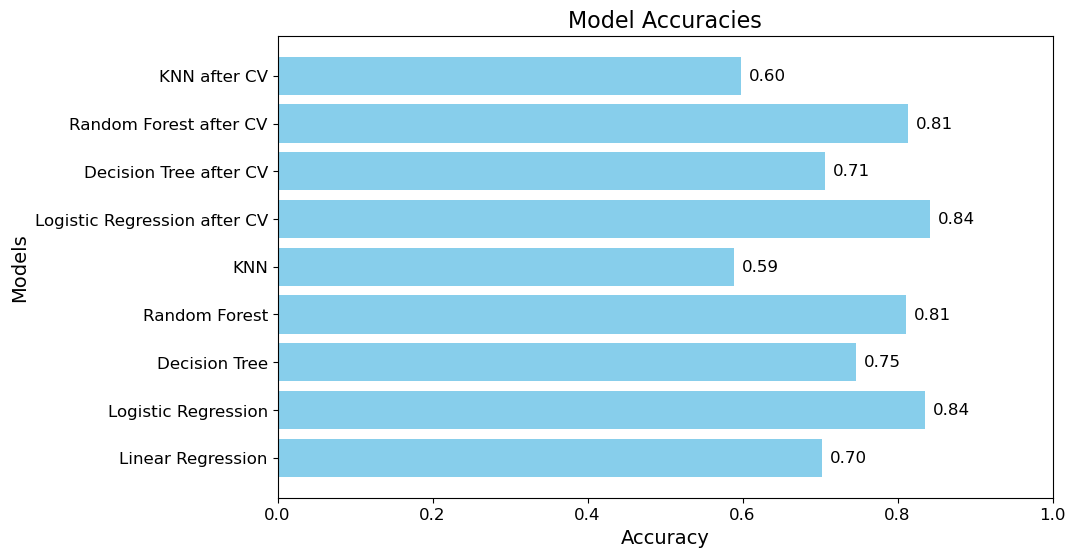

In [53]:
models = ['Linear Regression', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 
          'Logistic Regression after CV', 'Decision Tree after CV', 'Random Forest after CV', 'KNN after CV']
accuracies = accuracy['BoW']
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(models, accuracies, color='skyblue')
ax.set_title('Model Accuracies', fontsize=16)
ax.set_xlabel('Accuracy', fontsize=14)
ax.set_ylabel('Models', fontsize=14)
ax.set_xlim(0, 1)
ax.tick_params(axis='both', labelsize=12)
for i, acc in enumerate(accuracies):
    ax.text(acc+0.01, i, f'{acc:.2f}', va='center', fontsize=12)

plt.show()

# Comparision of both the techniques (TF-IDF vs BOW):

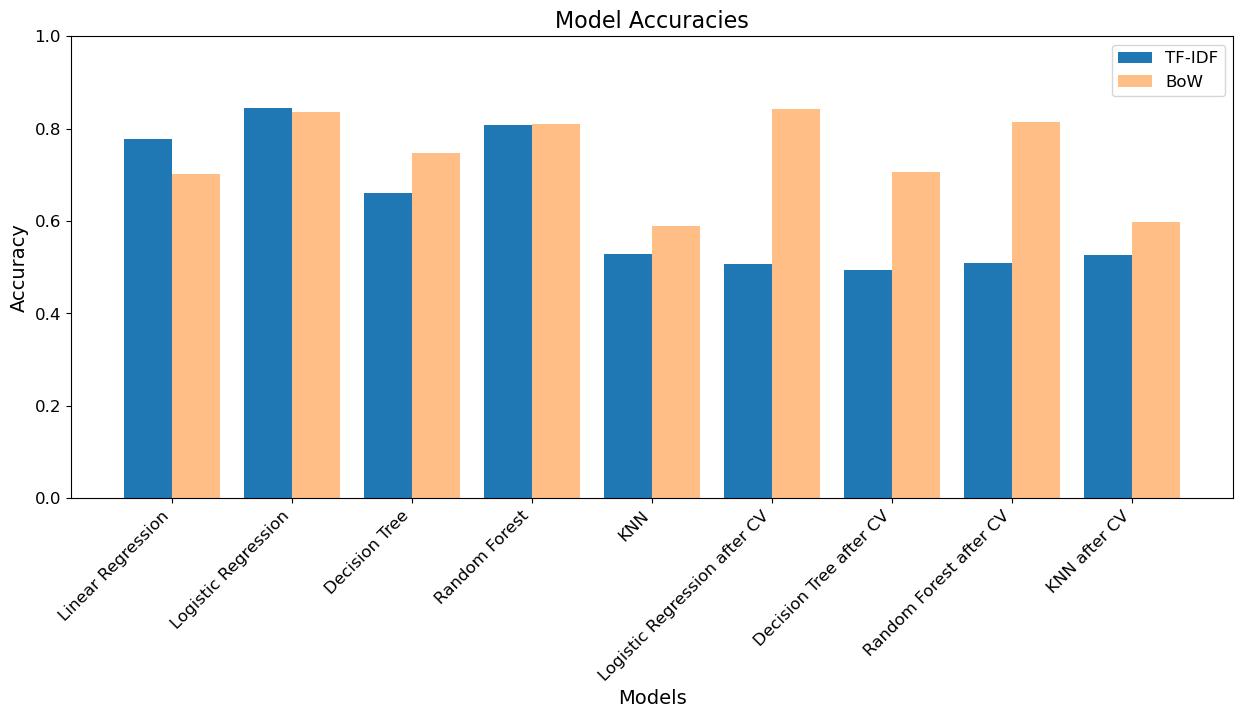

In [54]:
models = ['Linear Regression', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN',  'Logistic Regression after CV', 'Decision Tree after CV', 'Random Forest after CV', 'KNN after CV']

tfidf_acc = accuracy['TF-IDF']
bow_acc = accuracy['BoW']

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - 0.2, tfidf_acc, width=0.4, label='TF-IDF')
ax.bar(x + 0.2, bow_acc, width=0.4, label='BoW', alpha=0.5)
ax.set_title('Model Accuracies', fontsize=16)
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_ylim(0, 1)
ax.legend(fontsize=12)
ax.tick_params(axis='both', labelsize=12)
plt.xticks(x, models, rotation=45, ha='right')
plt.show()

# Using Basic Neural Networks

## 1. BoW:

In [188]:
import tensorflow as tf
 
# 75% of the data is selected
train_df = df_range.sample(frac=0.75, random_state=4)
 
# it drops the training data
# from the original dataframe
val_df = df_range.drop(train_df.index)

In [189]:
X = df_range['text']
y = df_range['label']

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

In [190]:
Accuracies1 = []

In [191]:
Accuracies2 = []

## Scaling Out:

In [192]:
# calling to (0,1) range
max_val = X.max()
min_val = X.min()
 
range = max_val - min_val
X = (X - min_val)/(range)
 
#val_df =  (val_df- min_val)/range

In [193]:
y1=[0,1]

In [194]:
X.shape

(3646, 18591)

In [195]:
print(X)

  (0, 364)	0.038461538461538464
  (0, 478)	0.038461538461538464
  (0, 483)	0.038461538461538464
  (0, 999)	0.038461538461538464
  (0, 1423)	0.07692307692307693
  (0, 1756)	0.038461538461538464
  (0, 2025)	0.038461538461538464
  (0, 2116)	0.038461538461538464
  (0, 2238)	0.15384615384615385
  (0, 2832)	0.038461538461538464
  (0, 3686)	0.038461538461538464
  (0, 3750)	0.038461538461538464
  (0, 4263)	0.038461538461538464
  (0, 4396)	0.038461538461538464
  (0, 5499)	0.07692307692307693
  (0, 5903)	0.038461538461538464
  (0, 5978)	0.038461538461538464
  (0, 6552)	0.038461538461538464
  (0, 7593)	0.038461538461538464
  (0, 7867)	0.038461538461538464
  (0, 9401)	0.038461538461538464
  (0, 9420)	0.038461538461538464
  (0, 9606)	0.038461538461538464
  (0, 9802)	0.038461538461538464
  (0, 9834)	0.038461538461538464
  :	:
  (3644, 17985)	0.038461538461538464
  (3644, 18224)	0.07692307692307693
  (3644, 18418)	0.038461538461538464
  (3644, 18442)	0.07692307692307693
  (3645, 14)	0.038461538461538

In [196]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.toarray()
X_test = X_test.toarray()

# Creating a Multilayered Neural Network

## 1. 2 Relu and 1 tanh layers:

In [197]:
import tensorflow as tf
model = tf.keras.Sequential([
 
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1,activation='tanh')
])

In [198]:
# adam optimizer works pretty well for
# all kinds of problems and is a good starting point
model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy())

In [199]:
losses = model.fit(X_train, y_train,
 
                   validation_data=(X_train, y_train),
                    
                   # it will use 'batch_size' number
                   # of examples per example
                   batch_size=256,
                   epochs=15,  # total epoch
 
                   )

Epoch 1/15
12/12 [==============================] - 2s 86ms/step - loss: 1.7601 - val_loss: 1.0931
Epoch 2/15
12/12 [==============================] - 0s 42ms/step - loss: 0.9642 - val_loss: 0.8383
Epoch 3/15
12/12 [==============================] - 1s 45ms/step - loss: 0.7846 - val_loss: 0.7270
Epoch 4/15
12/12 [==============================] - 1s 44ms/step - loss: 0.7013 - val_loss: 0.6716
Epoch 5/15
12/12 [==============================] - 1s 43ms/step - loss: 0.6567 - val_loss: 0.6360
Epoch 6/15
12/12 [==============================] - 1s 45ms/step - loss: 0.6236 - val_loss: 0.6036
Epoch 7/15
12/12 [==============================] - 1s 45ms/step - loss: 0.5907 - val_loss: 0.5683
Epoch 8/15
12/12 [==============================] - 1s 49ms/step - loss: 0.5535 - val_loss: 0.5292
Epoch 9/15
12/12 [==============================] - 1s 44ms/step - loss: 0.5128 - val_loss: 0.4857
Epoch 10/15
12/12 [==============================] - 1s 44ms/step - loss: 0.4680 - val_loss: 0.4394
Epoch 11/

<Axes: >

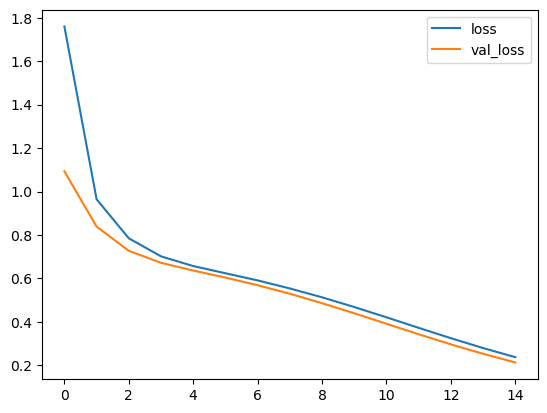

In [200]:
loss_df = pd.DataFrame(losses.history)
 
# history stores the loss/val
# loss in each epoch
 
# loss_df is a dataframe which
# contains the losses so we can
# plot it to visualize our model training
loss_df.loc[:,['loss','val_loss']].plot()

In [201]:
predictions=model.predict(X_test);
predictions_oned = predictions.flatten()
modified_array = np.where(predictions_oned <= 0.5, 0, 1)


correct_predictions = np.sum(modified_array== y_test)

# Calculate accuracy
accuracy = correct_predictions / len(y_test)

Accuracies1.append(accuracy)

#print("Accuracy:", accuracy)
print("Accuracy:", accuracy)

23/23 [==============================] - 0s 3ms/step
Accuracy: 0.8273972602739726


## 2. 2 relu 2 elu 1 sigmoid layer

In [202]:
import tensorflow as tf
model = tf.keras.Sequential([
 
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='elu'),
    tf.keras.layers.Dense(units=64, activation='elu'),
    tf.keras.layers.Dense(units=1,activation='sigmoid')
])

In [203]:
model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy())

In [204]:
X = df_range['text']
y = df_range['label']

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

max_val = X.max()
min_val = X.min()
 
range = max_val - min_val
X = (X - min_val)/(range)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.toarray()
X_test = X_test.toarray()

losses = model.fit(X_train, y_train,
 
                   validation_data=(X_train, y_train),
                    
                   # it will use 'batch_size' number
                   # of examples per example
                   batch_size=256,
                   epochs=15,  # total epoch
 
                   )

Epoch 1/15
12/12 [==============================] - 2s 87ms/step - loss: 0.6897 - val_loss: 0.6697
Epoch 2/15
12/12 [==============================] - 1s 44ms/step - loss: 0.6290 - val_loss: 0.5211
Epoch 3/15
12/12 [==============================] - 1s 45ms/step - loss: 0.4031 - val_loss: 0.2203
Epoch 4/15
12/12 [==============================] - 1s 43ms/step - loss: 0.1519 - val_loss: 0.0672
Epoch 5/15
12/12 [==============================] - 1s 45ms/step - loss: 0.0471 - val_loss: 0.0207
Epoch 6/15
12/12 [==============================] - 1s 46ms/step - loss: 0.0148 - val_loss: 0.0073
Epoch 7/15
12/12 [==============================] - 1s 49ms/step - loss: 0.0056 - val_loss: 0.0031
Epoch 8/15
12/12 [==============================] - 1s 45ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 9/15
12/12 [==============================] - 1s 45ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 10/15
12/12 [==============================] - 1s 43ms/step - loss: 0.0011 - val_loss: 9.2000e-04
Epoch

<Axes: >

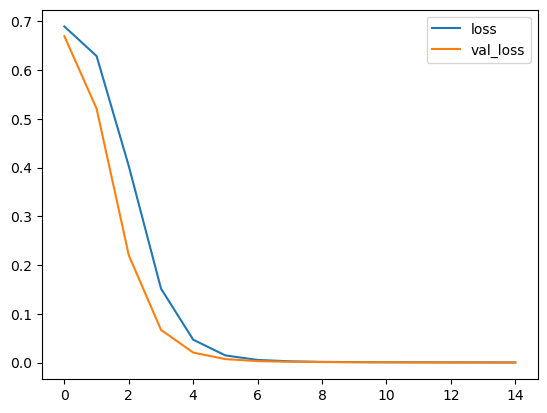

In [205]:
loss_df = pd.DataFrame(losses.history)
 
# history stores the loss/val
# loss in each epoch
 
# loss_df is a dataframe which
# contains the losses so we can
# plot it to visualize our model training
loss_df.loc[:,['loss','val_loss']].plot()

In [206]:
predictions=model.predict(X_test);
predictions_oned = predictions.flatten()
modified_array = np.where(predictions_oned <= 0.5, 0, 1)


correct_predictions = np.sum(modified_array== y_test)

# Calculate accuracy
accuracy = correct_predictions / len(y_test)
Accuracies1.append(accuracy)

#print("Accuracy:", accuracy)
print("Accuracy:", accuracy)

23/23 [==============================] - 0s 4ms/step
Accuracy: 0.836986301369863


# 2. TF-IDF

In [207]:
X = df_range['text']
y = df_range['label']

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

In [208]:

max_val = X.max()
min_val = X.min()
 
range = max_val - min_val
X = (X - min_val)/(range)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.toarray()
X_test = X_test.toarray()

## 1. 2 Relu and 1 tanh layers:

In [209]:
import tensorflow as tf
model = tf.keras.Sequential([
 
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1,activation='tanh')
])

In [210]:
model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy())

In [211]:
losses = model.fit(X_train, y_train,
 
                   validation_data=(X_train, y_train),
                    
                   # it will use 'batch_size' number
                   # of examples per example
                   batch_size=256,
                   epochs=15,  # total epoch
 
                   )

Epoch 1/15
12/12 [==============================] - 2s 83ms/step - loss: 1.3743 - val_loss: 0.7836
Epoch 2/15
12/12 [==============================] - 0s 42ms/step - loss: 0.6934 - val_loss: 0.6112
Epoch 3/15
12/12 [==============================] - 1s 44ms/step - loss: 0.5839 - val_loss: 0.5364
Epoch 4/15
12/12 [==============================] - 1s 42ms/step - loss: 0.5062 - val_loss: 0.4522
Epoch 5/15
12/12 [==============================] - 0s 41ms/step - loss: 0.4191 - val_loss: 0.3660
Epoch 6/15
12/12 [==============================] - 0s 41ms/step - loss: 0.3363 - val_loss: 0.2885
Epoch 7/15
12/12 [==============================] - 1s 45ms/step - loss: 0.2628 - val_loss: 0.2217
Epoch 8/15
12/12 [==============================] - 0s 40ms/step - loss: 0.2007 - val_loss: 0.1676
Epoch 9/15
12/12 [==============================] - 0s 40ms/step - loss: 0.1518 - val_loss: 0.1259
Epoch 10/15
12/12 [==============================] - 0s 41ms/step - loss: 0.1136 - val_loss: 0.0932
Epoch 11/

<Axes: >

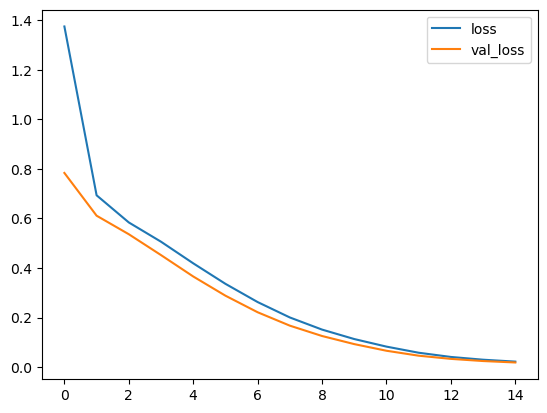

In [212]:
loss_df = pd.DataFrame(losses.history)
 
# history stores the loss/val
# loss in each epoch
 
# loss_df is a dataframe which
# contains the losses so we can
# plot it to visualize our model training
loss_df.loc[:,['loss','val_loss']].plot()

In [213]:
predictions=model.predict(X_test);
predictions_oned = predictions.flatten()
modified_array = np.where(predictions_oned <= 0.5, 0, 1)


correct_predictions = np.sum(modified_array== y_test)

# Calculate accuracy
accuracy = correct_predictions / len(y_test)
Accuracies2.append(accuracy)

#print("Accuracy:", accuracy)
print("Accuracy:", accuracy)

23/23 [==============================] - 0s 4ms/step
Accuracy: 0.7479452054794521


## 2. 2 relu 2 elu 1 sigmoid layer

In [214]:
import tensorflow as tf
model = tf.keras.Sequential([
 
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='elu'),
    tf.keras.layers.Dense(units=64, activation='elu'),
    tf.keras.layers.Dense(units=1,activation='sigmoid')
])

In [215]:
X = df_range['text']
y = df_range['label']

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

max_val = X.max()
min_val = X.min()
 
range = max_val - min_val
X = (X - min_val)/(range)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.toarray()
X_test = X_test.toarray()

model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy())

losses = model.fit(X_train, y_train,
 
                   validation_data=(X_train, y_train),
                    
                   # it will use 'batch_size' number
                   # of examples per example
                   batch_size=256,
                   epochs=15,  # total epoch
 
                   )

Epoch 1/15
12/12 [==============================] - 2s 84ms/step - loss: 0.6809 - val_loss: 0.6021
Epoch 2/15
12/12 [==============================] - 1s 44ms/step - loss: 0.4830 - val_loss: 0.2369
Epoch 3/15
12/12 [==============================] - 0s 42ms/step - loss: 0.1331 - val_loss: 0.0300
Epoch 4/15
12/12 [==============================] - 1s 45ms/step - loss: 0.0156 - val_loss: 0.0025
Epoch 5/15
12/12 [==============================] - 0s 42ms/step - loss: 0.0010 - val_loss: 4.8606e-04
Epoch 6/15
12/12 [==============================] - 1s 45ms/step - loss: 3.6545e-04 - val_loss: 2.6047e-04
Epoch 7/15
12/12 [==============================] - 1s 47ms/step - loss: 2.3070e-04 - val_loss: 1.9526e-04
Epoch 8/15
12/12 [==============================] - 0s 43ms/step - loss: 1.7922e-04 - val_loss: 1.5983e-04
Epoch 9/15
12/12 [==============================] - 1s 43ms/step - loss: 1.5023e-04 - val_loss: 1.3678e-04
Epoch 10/15
12/12 [==============================] - 0s 41ms/step - loss:

In [216]:
predictions=model.predict(X_test);
predictions_oned = predictions.flatten()
modified_array = np.where(predictions_oned <= 0.5, 0, 1)


correct_predictions = np.sum(modified_array== y_test)

# Calculate accuracy
accuracy = correct_predictions / len(y_test)
Accuracies2.append(accuracy)

#print("Accuracy:", accuracy)
print("Accuracy:", accuracy)

23/23 [==============================] - 0s 3ms/step
Accuracy: 0.8232876712328767


In [217]:
Accuracies1

[0.8273972602739726, 0.836986301369863]

In [218]:
Accuracies2

[0.7479452054794521, 0.8232876712328767]

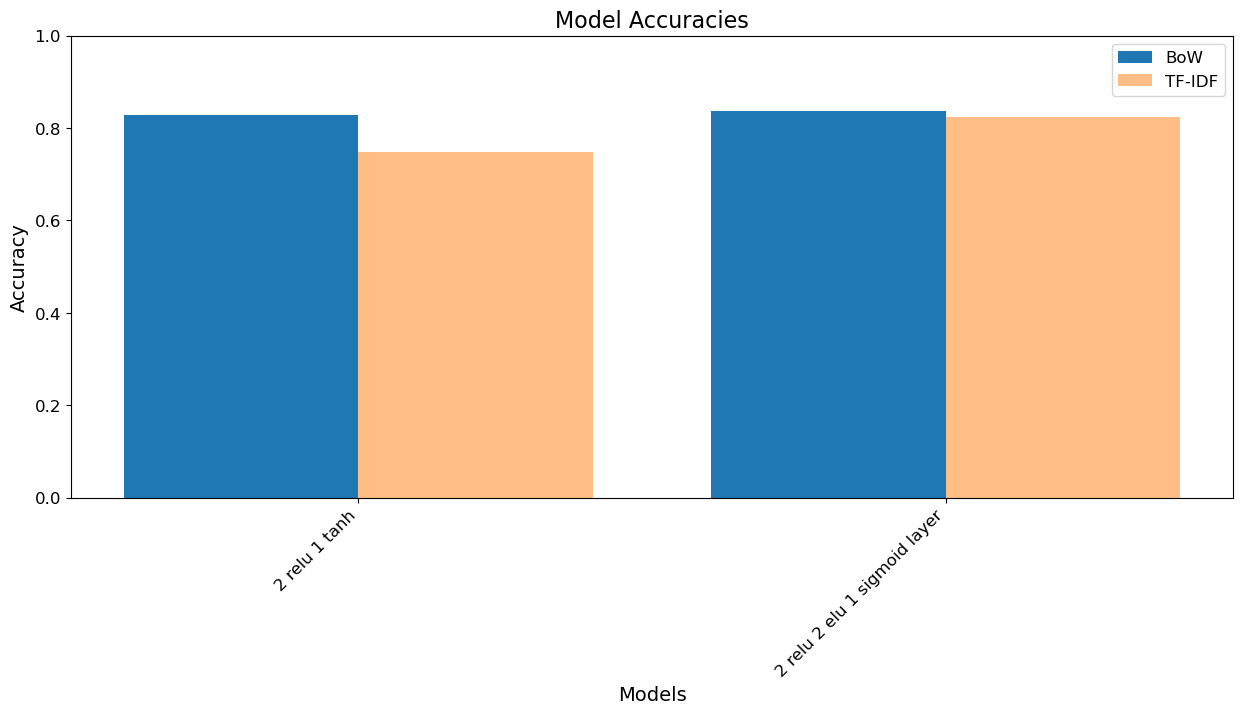

In [219]:
models = ['2 relu 1 tanh', '2 relu 2 elu 1 sigmoid layer']



x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - 0.2, Accuracies1, width=0.4, label='BoW')
ax.bar(x + 0.2, Accuracies2, width=0.4, label='TF-IDF', alpha=0.5)
ax.set_title('Model Accuracies', fontsize=16)
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_ylim(0, 1)
ax.legend(fontsize=12)
ax.tick_params(axis='both', labelsize=12)
plt.xticks(x, models, rotation=45, ha='right')
plt.show()

# Conclusion

Thank you 